<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/Module3_Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 4
Task 1:Generate synthetic image with random blobs.
Task 2:Object segmentation and labeling
Task 3:Get regional properties in a pandas dataframe
Task 4:Analyze blobs.
Task 5:Obtain texture-based regional properties.

/tmp/ipykernel_2586/1525382919.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(img)


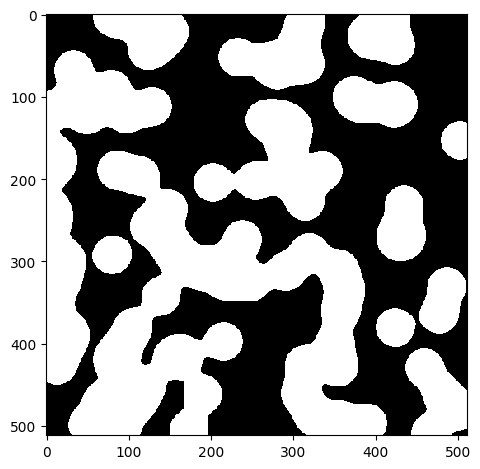

In [23]:
import skimage as sk
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
from skimage.measure import label
from skimage.color import label2rgb
img=sk.data.binary_blobs()
sk.io.imshow(img)

/usr/local/lib/python3.12/dist-packages/skimage/exposure/exposure.py:306: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bin_edges = np.histogram(image, bins=bins, range=hist_range)


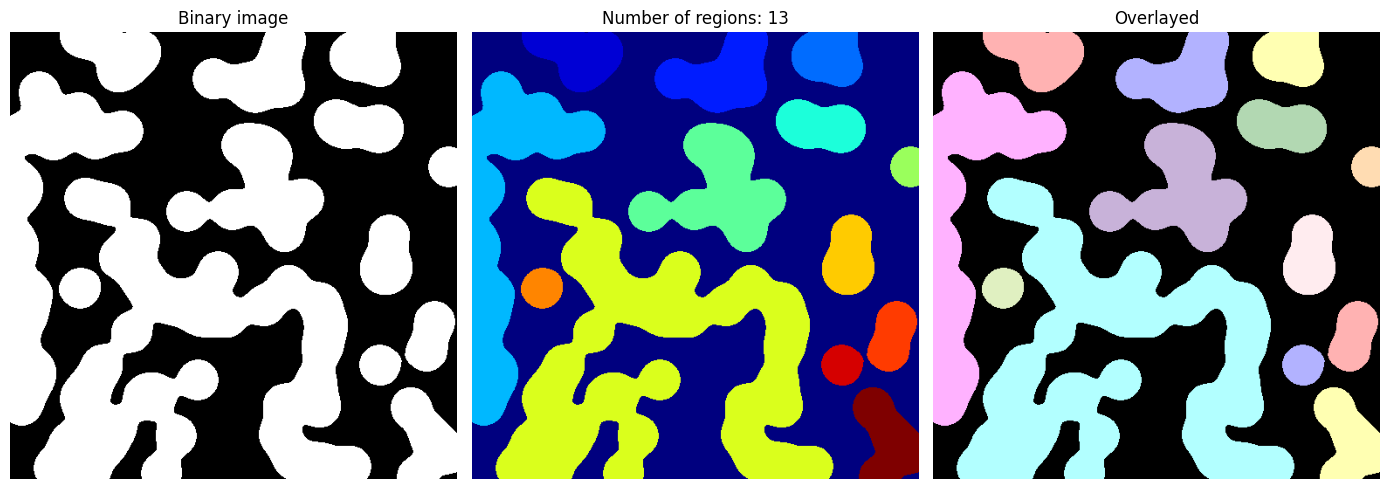

In [24]:
threeshold=threshold_otsu(img)
img_binary=img>threeshold
from skimage.filters import threshold_otsu
from skimage.measure import label
import matplotlib.pyplot as plt
import numpy as np
label_image, nregions = label(img_binary, return_num=True)
image_label_overlay = label2rgb(label_image, image=img, bg_label=0)
label_image = label_image.astype(np.int16)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
ax = axes.ravel()
ax[0].imshow(img_binary, cmap='gray')
ax[0].set_title('Binary image')
ax[1].imshow(label_image, cmap='jet')
ax[1].set_title(f'Number of regions: {nregions}')
ax[2].imshow(image_label_overlay)
ax[2].set_title(f'Overlayed')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
plt.tight_layout()
plt.show()

In [29]:
from skimage.measure import label, regionprops_table
import pandas as pd
props = regionprops_table(
    label_image,
    intensity_image=img,
    properties=('label','area','eccentricity','extent','axis_major_length'))
df = pd.DataFrame(props)
print(df)

    label     area  eccentricity    extent  axis_major_length
0       1   5432.0      0.799989  0.678661         113.942397
1       2   7835.0      0.805885  0.648056         140.920299
2       3   4271.0      0.650568  0.826752          85.496694
3       4  21881.0      0.964830  0.352249         486.234806
4       5   4886.0      0.852612  0.765111         110.288489
5       6  13388.0      0.510326  0.499776         166.269374
6       7   1281.0      0.701821  0.825919          48.587094
7       8  55471.0      0.532041  0.415466         415.691928
8       9   4310.0      0.794434  0.780797          95.951717
9      10   1761.0      0.299726  0.780585          48.491564
10     11   3340.0      0.817150  0.710941          86.533637
11     12   1757.0      0.242216  0.762918          48.038110
12     13   5459.0      0.832505  0.684085         120.001376


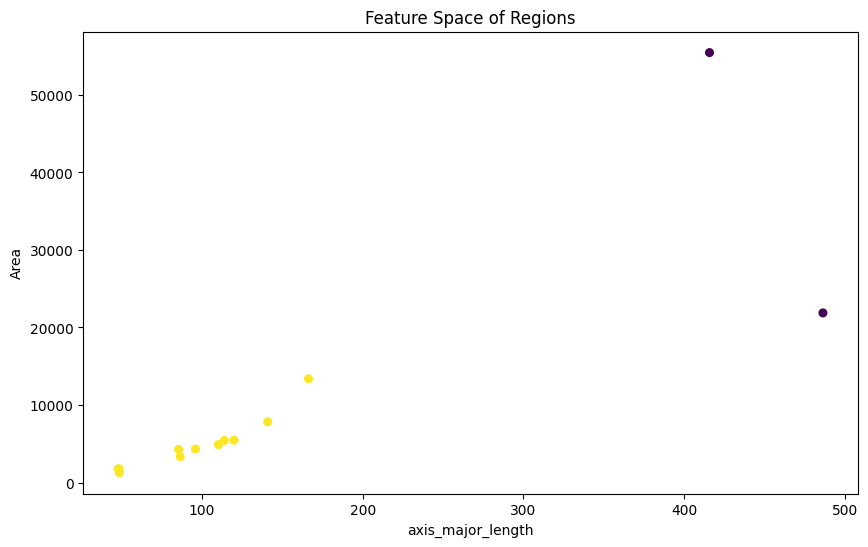

In [36]:
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops, regionprops_table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
props = regionprops(label_image)
features = np.zeros((len(props), 3))
labels = np.zeros(len(props))
for i, region in enumerate(props):
    features[i, 0] = region.axis_major_length
    features[i, 1] = region.area
    features[i, 2] = region.solidity
    row, col = map(int, region.centroid)
    labels[i] = img_binary[row, col]
plt.figure(figsize=(10, 6))
plt.scatter(
    features[:, 0],
    features[:, 1],
    s=30,
    c=labels,
    marker='o'
)

plt.xlabel('axis_major_length')
plt.ylabel('Area')
plt.title('Feature Space of Regions')
plt.show()

There are 10 blobs with an area larger or equal the mean area and also 24 blobs with an area smaller than the mean area

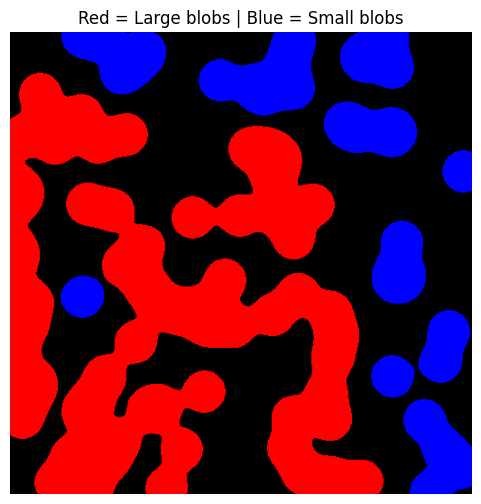

In [37]:
import numpy as np
import matplotlib.pyplot as plt
mean_area = df['area'].mean()
large_labels = df[df['area'] >= mean_area]['label'].values
small_labels = df[df['area'] < mean_area]['label'].values
large_mask = np.isin(label_image, large_labels)
small_mask = np.isin(label_image, small_labels)
result = np.zeros((*label_image.shape, 3))
result[large_mask] = [1, 0, 0]
result[small_mask] = [0, 0, 1]
plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Red = Large blobs | Blue = Small blobs")
plt.axis('off')
plt.show()

In [41]:
from skimage.measure import regionprops_table
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from skimage.filters.rank import entropy
from skimage.morphology import disk
from skimage.util import img_as_ubyte
texture_df = pd.DataFrame(regionprops_table(
    label_image,
    intensity_image=img,
    properties=(
        'label',
        'area',
        'mean_intensity',
        'min_intensity',
        'max_intensity',
        'intensity_std'
    )
))
entropy_img = entropy(img_as_ubyte(img), disk(5))
props = regionprops(label_image, intensity_image=entropy_img)
texture_df['entropy'] = [p.mean_intensity for p in props]
print(texture_df)

    label     area  mean_intensity  min_intensity  max_intensity  \
0       1   5432.0             1.0            1.0            1.0   
1       2   7835.0             1.0            1.0            1.0   
2       3   4271.0             1.0            1.0            1.0   
3       4  21881.0             1.0            1.0            1.0   
4       5   4886.0             1.0            1.0            1.0   
5       6  13388.0             1.0            1.0            1.0   
6       7   1281.0             1.0            1.0            1.0   
7       8  55471.0             1.0            1.0            1.0   
8       9   4310.0             1.0            1.0            1.0   
9      10   1761.0             1.0            1.0            1.0   
10     11   3340.0             1.0            1.0            1.0   
11     12   1757.0             1.0            1.0            1.0   
12     13   5459.0             1.0            1.0            1.0   

    intensity_std   entropy  
0             0.0